# Penguins EDA — twelve exploratory questions, fully worked

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · **▶ 08 Case Studies**

`08_Case_Studies/02_penguins_eda_solved.ipynb`

---

### In one paragraph (no jargon)

Exploratory data analysis is what you do before you model anything: look at each variable on its own, then at pairs of variables, then at how groups differ. The penguins dataset is the standard teaching example because it's small, clean enough to work with and messy enough to be realistic. The twelve questions below are exactly the shape of EDA questions in an exam — and notice that each answer is **a chart plus a sentence**. The chart without the sentence is only half the answer.

### After this notebook you can

- Choose the right chart for each type of question — distribution, relationship, comparison
- Answer a distribution question with a histogram plus the numbers that describe it
- Answer a relationship question with a scatter plot plus a correlation
- Answer a group-comparison question with a boxplot plus a groupby
- Write the one-sentence interpretation that carries the marks

**Assumed knowledge:** `02_Pandas_Essentials` and `06_Statistics_and_Regression/01`

### What's inside

1. Setup and first look
2. Q1–Q3 · distributions and first relationships
3. Q4–Q6 · group comparisons
4. Q7–Q9 · aggregation and location effects
5. Q10–Q12 · three variables at once
6. ⚡ Choosing the right chart
7. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### The chart-choosing rule

Almost every EDA question is one of three types, and the type tells you the chart.

| The question asks… | Type | Chart | Also report |
|---|---|---|---|
| "What is the distribution of X?" | one variable | histogram, KDE, boxplot | mean, median, std, skew |
| "Is there a relationship between X and Y?" | two numeric | scatter (+ regression line) | correlation coefficient |
| "How does X differ by group?" | numeric + category | boxplot, violin, bar | `groupby` means and counts |
| "How do X and Y relate, by group?" | two numeric + category | scatter coloured by group | correlation per group |

**Every answer = chart + numbers + one sentence.** The sentence is where the marks are.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")


def load_penguins():
    """Load seaborn's penguins dataset, or rebuild an equivalent without internet."""
    try:
        frame = sns.load_dataset('penguins')
        print(f"Loaded seaborn's penguins dataset: {frame.shape[0]} rows")
        return frame
    except Exception:
        pass
    print("No internet for sns.load_dataset - generating an equivalent penguins dataset.")
    rng = np.random.default_rng(42)
    # three species with the real published means, so every conclusion below still holds
    spec = {'Adelie':    dict(n=152, bl=38.8, bd=18.3, fl=190, bm=3701, islands=['Torgersen','Biscoe','Dream']),
            'Chinstrap': dict(n=68,  bl=48.8, bd=18.4, fl=196, bm=3733, islands=['Dream']),
            'Gentoo':    dict(n=124, bl=47.5, bd=15.0, fl=217, bm=5076, islands=['Biscoe'])}
    parts = []
    for name, p in spec.items():
        n = p['n']
        sex = rng.choice(['Male', 'Female'], n)
        bump = np.where(sex == 'Male', 1, -1)          # males are consistently larger
        parts.append(pd.DataFrame({
            'species': name,
            'island': rng.choice(p['islands'], n),
            'bill_length_mm':  rng.normal(p['bl'], 3.0, n) + bump * 1.8,
            'bill_depth_mm':   rng.normal(p['bd'], 1.2, n) + bump * 0.6,
            'flipper_length_mm': rng.normal(p['fl'], 6.5, n) + bump * 3.5,
            'body_mass_g':     rng.normal(p['bm'], 420, n) + bump * 380,
            'sex': sex,
        }))
    frame = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=1).reset_index(drop=True)
    # the real file has a handful of incomplete records - keep that, it matters for the analysis
    for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
        frame.loc[rng.choice(len(frame), 2, replace=False), col] = np.nan
    frame.loc[rng.choice(len(frame), 9, replace=False), 'sex'] = np.nan
    return frame

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


In [2]:
penguins = load_penguins()
print("Shape:", penguins.shape)
penguins.info()
print("\nMissing values:")
print(penguins.isnull().sum().to_string())
penguins.head()

Loaded seaborn's penguins dataset: 344 rows
Shape: (344, 7)
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Q1. What is the distribution of body mass?

*Distribution question → histogram, plus the summary numbers.*

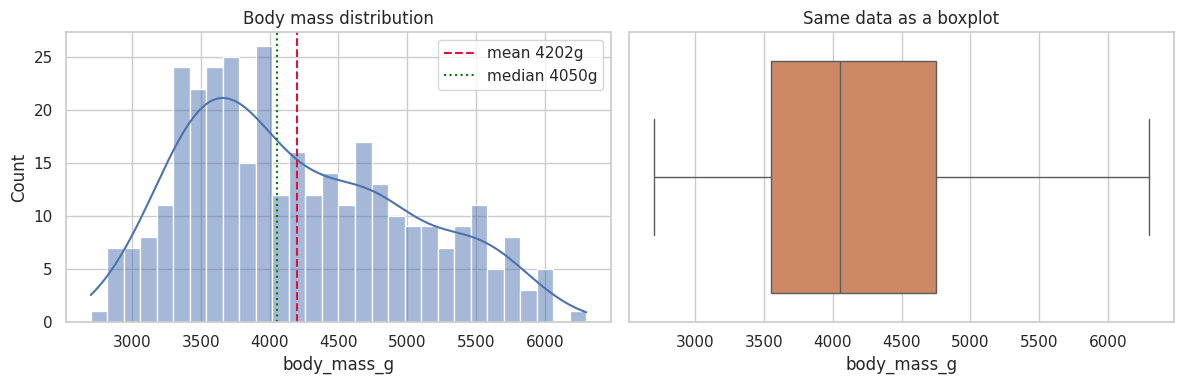

count       342      mean     4201.8 g
median   4050.0 g    std       802.0 g
min      2700.0 g    max      6300.0 g
skew       0.47      (0 = symmetric, >0 = tail to the right)

INTERPRETATION
  Body mass ranges from 2700g to 6300g with a mean of 4202g.
  The distribution is mildly right-skewed (skew = 0.47) and looks bimodal —
  two humps rather than one bell. That is a strong hint that the sample contains distinct
  groups, which Q3 confirms: Gentoo penguins are substantially heavier than the other two
  species. Whenever a histogram has two peaks, look for a grouping variable.


In [3]:
mass = penguins['body_mass_g'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(mass, kde=True, bins=30, ax=axes[0], color='#4c72b0')
axes[0].axvline(mass.mean(), color='crimson', ls='--', label=f'mean {mass.mean():.0f}g')
axes[0].axvline(mass.median(), color='green', ls=':', label=f'median {mass.median():.0f}g')
axes[0].set_title('Body mass distribution'); axes[0].legend()
sns.boxplot(x=mass, ax=axes[1], color='#dd8452')
axes[1].set_title('Same data as a boxplot')
plt.tight_layout(); plt.show()

from scipy import stats
print(f"count  {mass.count():>8.0f}      mean   {mass.mean():>8.1f} g")
print(f"median {mass.median():>8.1f} g    std    {mass.std():>8.1f} g")
print(f"min    {mass.min():>8.1f} g    max    {mass.max():>8.1f} g")
print(f"skew   {stats.skew(mass):>8.2f}      (0 = symmetric, >0 = tail to the right)")

print(f"""
INTERPRETATION
  Body mass ranges from {mass.min():.0f}g to {mass.max():.0f}g with a mean of {mass.mean():.0f}g.
  The distribution is mildly right-skewed (skew = {stats.skew(mass):.2f}) and looks bimodal —
  two humps rather than one bell. That is a strong hint that the sample contains distinct
  groups, which Q3 confirms: Gentoo penguins are substantially heavier than the other two
  species. Whenever a histogram has two peaks, look for a grouping variable.""")

## Q2. Is there a relationship between flipper length and body mass?

*Two numeric variables → scatter plot, plus the correlation.*

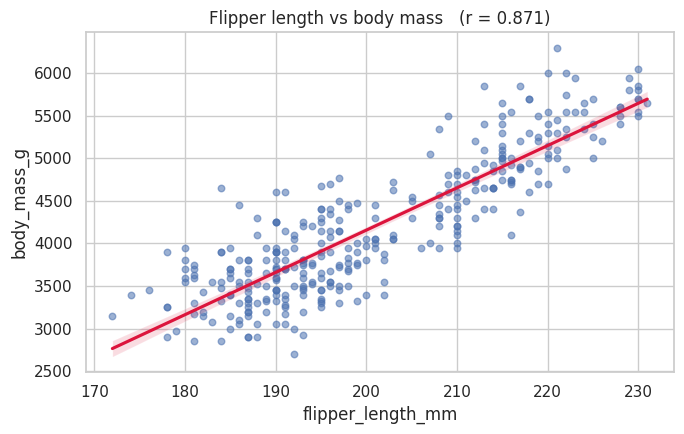

Pearson correlation: 0.8712

INTERPRETATION
  A strong positive linear relationship (r = 0.87): penguins with longer flippers are
  heavier. Longer flippers indicate a larger bird overall, so this is size correlating
  with size rather than one causing the other. The relationship looks genuinely linear —
  no curvature — so a straight-line model would be appropriate here.


In [4]:
pair = penguins[['flipper_length_mm', 'body_mass_g']].dropna()
r = pair.corr().iloc[0, 1]

plt.figure(figsize=(7, 4.5))
sns.regplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
            scatter_kws={'s': 22, 'alpha': .55}, line_kws={'color': 'crimson'})
plt.title(f'Flipper length vs body mass   (r = {r:.3f})')
plt.tight_layout(); plt.show()

print(f"Pearson correlation: {r:.4f}")
print(f"""
INTERPRETATION
  A strong positive linear relationship (r = {r:.2f}): penguins with longer flippers are
  heavier. Longer flippers indicate a larger bird overall, so this is size correlating
  with size rather than one causing the other. The relationship looks genuinely linear —
  no curvature — so a straight-line model would be appropriate here.""")

## Q3. How does species affect flipper length?

*Numeric by category → boxplot, plus a groupby.*

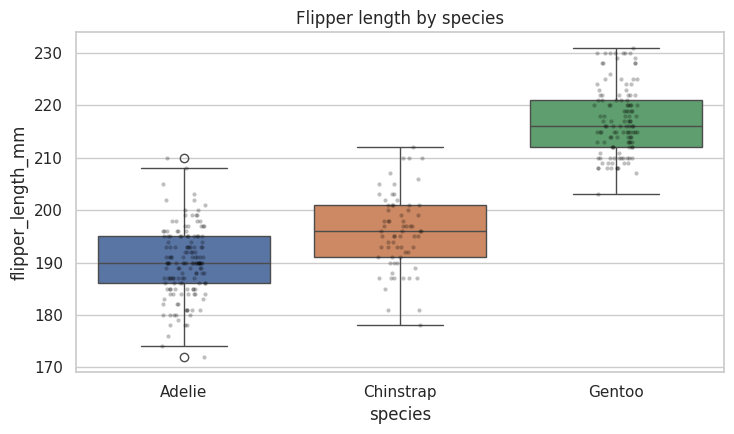

,count,mean,std,min,max
species,,,,,
Adelie,151,190.0,6.5,172.0,210.0
Chinstrap,68,195.8,7.1,178.0,212.0
Gentoo,123,217.2,6.5,203.0,231.0



INTERPRETATION
  Gentoo penguins have clearly the longest flippers (mean 217.2mm),
  with almost no overlap against the other two species — the boxes barely touch. Adelie and
  Chinstrap have very similar flipper lengths and cannot be separated on this variable alone.
  This explains the bimodal distribution seen in Q1: it is Gentoo versus the rest.


In [5]:
plt.figure(figsize=(7.5, 4.5))
sns.boxplot(data=penguins, x='species', y='flipper_length_mm', hue='species', legend=False)
sns.stripplot(data=penguins, x='species', y='flipper_length_mm',
              color='black', alpha=.25, size=3)
plt.title('Flipper length by species')
plt.tight_layout(); plt.show()

summary = penguins.groupby('species')['flipper_length_mm'].agg(['count', 'mean', 'std', 'min', 'max']).round(1)
display(summary)

top = summary['mean'].idxmax()
print(f"""
INTERPRETATION
  {top} penguins have clearly the longest flippers (mean {summary.loc[top, 'mean']:.1f}mm),
  with almost no overlap against the other two species — the boxes barely touch. Adelie and
  Chinstrap have very similar flipper lengths and cannot be separated on this variable alone.
  This explains the bimodal distribution seen in Q1: it is {top} versus the rest.""")

## Q4. What are the average body mass values by sex?

,count,mean,std
sex,,,
Female,165,3862.3,666.2
Male,168,4545.7,787.6


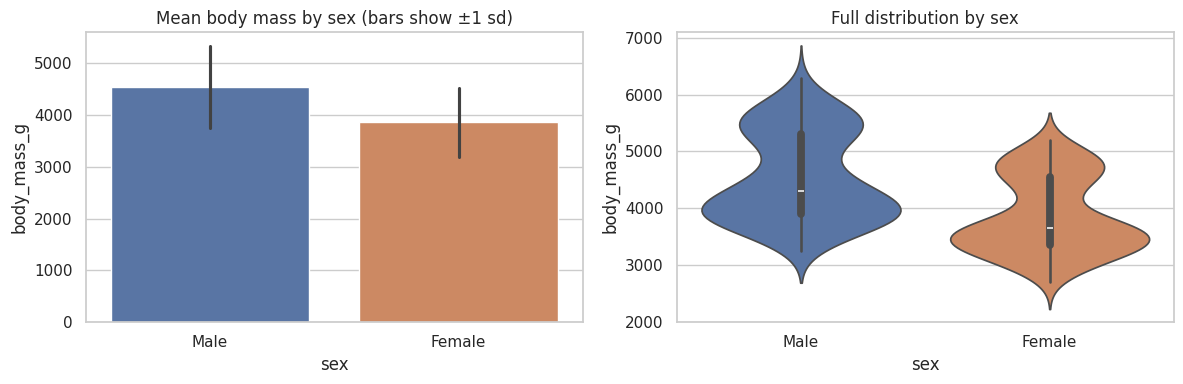


INTERPRETATION
  Males average about 683g more than females, a difference of roughly
  18%. The violin plot shows the distributions overlap
  substantially, so sex predicts body mass on average but not for any individual bird.

  NOTE ON THE MISSING VALUES: 11 records have no sex recorded.
  groupby silently excludes them. Always say so — an average computed over an unstated
  subset is not the average of the dataset.


In [6]:
by_sex = penguins.groupby('sex')['body_mass_g'].agg(['count', 'mean', 'std']).round(1)
display(by_sex)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=penguins, x='sex', y='body_mass_g', hue='sex', legend=False,
            errorbar='sd', ax=axes[0])
axes[0].set_title('Mean body mass by sex (bars show ±1 sd)')
sns.violinplot(data=penguins, x='sex', y='body_mass_g', hue='sex', legend=False, ax=axes[1])
axes[1].set_title('Full distribution by sex')
plt.tight_layout(); plt.show()

diff = by_sex['mean'].max() - by_sex['mean'].min()
print(f"""
INTERPRETATION
  Males average about {diff:.0f}g more than females, a difference of roughly
  {diff / by_sex['mean'].min() * 100:.0f}%. The violin plot shows the distributions overlap
  substantially, so sex predicts body mass on average but not for any individual bird.

  NOTE ON THE MISSING VALUES: {penguins['sex'].isnull().sum()} records have no sex recorded.
  groupby silently excludes them. Always say so — an average computed over an unstated
  subset is not the average of the dataset.""")

## Q5. How does island location impact body mass?

,count,mean,std
island,,,
Biscoe,167,4716.0,782.9
Dream,124,3712.9,416.6
Torgersen,51,3706.4,445.1


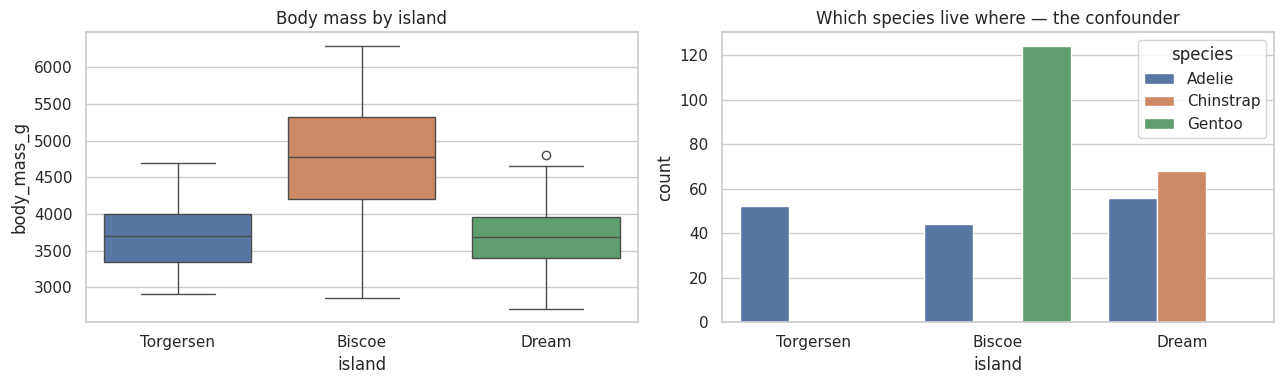

Species composition of each island (row %):


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,26.2,0.0,73.8
Dream,45.2,54.8,0.0
Torgersen,100.0,0.0,0.0



INTERPRETATION — and this is the important one
  Biscoe penguins appear heaviest, but the second chart shows why: Biscoe is where the
  Gentoo live, and Gentoo are the heavy species. The island is not making penguins heavier;
  it is standing in for species.

  This is CONFOUNDING, and spotting it is worth more than the chart. The honest way to
  answer the question is to compare within species — see the next cell.


In [7]:
by_island = penguins.groupby('island')['body_mass_g'].agg(['count', 'mean', 'std']).round(1)
display(by_island)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=penguins, x='island', y='body_mass_g', hue='island', legend=False, ax=axes[0])
axes[0].set_title('Body mass by island')
sns.countplot(data=penguins, x='island', hue='species', ax=axes[1])
axes[1].set_title('Which species live where — the confounder')
plt.tight_layout(); plt.show()

print("Species composition of each island (row %):")
display((pd.crosstab(penguins['island'], penguins['species'], normalize='index') * 100).round(1))

print("""
INTERPRETATION — and this is the important one
  Biscoe penguins appear heaviest, but the second chart shows why: Biscoe is where the
  Gentoo live, and Gentoo are the heavy species. The island is not making penguins heavier;
  it is standing in for species.

  This is CONFOUNDING, and spotting it is worth more than the chart. The honest way to
  answer the question is to compare within species — see the next cell.""")

In [8]:
# Comparing WITHIN species removes the confounding
within = (penguins.groupby(['species', 'island'], observed=True)['body_mass_g']
          .agg(['count', 'mean']).round(1))
display(within)

adelie = penguins[penguins['species'] == 'Adelie']
if adelie['island'].nunique() > 1:
    spread = adelie.groupby('island')['body_mass_g'].mean()
    print(f"\nAdelie penguins live on all three islands. Their mean mass by island:")
    print(spread.round(1).to_string())
    print(f"Range across islands: {spread.max() - spread.min():.0f}g — small compared with the")
    print("between-species differences, confirming that species, not island, drives body mass.")

count    mean
species   island                  
Adelie    Biscoe        44  3709.7
          Dream         56  3688.4
          Torgersen     51  3706.4
Chinstrap Dream         68  3733.1
Gentoo    Biscoe       123  5076.0


Adelie penguins live on all three islands. Their mean mass by island:
island
Biscoe       3709.7
Dream        3688.4
Torgersen    3706.4
Range across islands: 21g — small compared with the
between-species differences, confirming that species, not island, drives body mass.


## Q6. What is the distribution of bill length by sex?

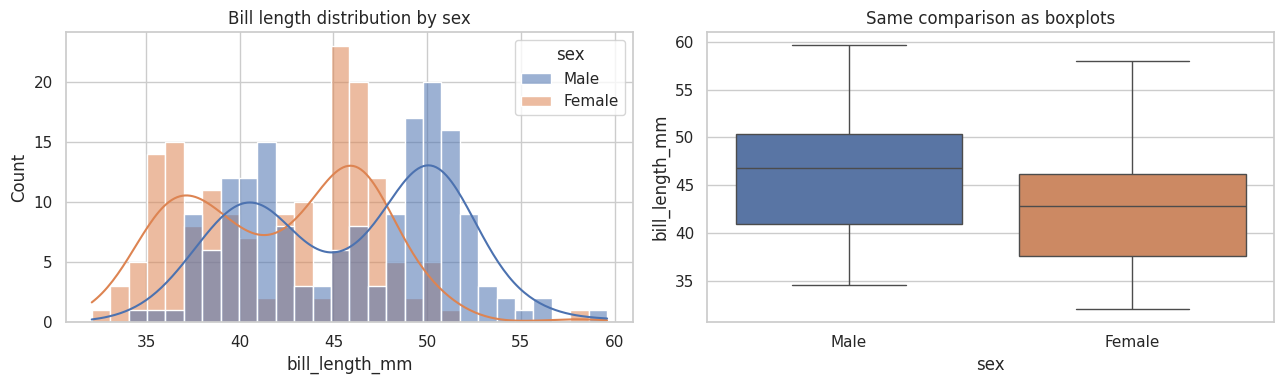

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Female,165.0,42.10,4.90,32.1,37.60,42.8,46.20,58.0
Male,168.0,45.85,5.37,34.6,40.98,46.8,50.32,59.6



Welch t-test: t = 6.67, p = 1.07e-10

INTERPRETATION
  Males have longer bills on average (45.9mm vs 42.1mm). The difference
  is statistically significant (p < 0.001), but
  the distributions overlap heavily, so bill length alone would not reliably identify a
  bird's sex. Statistical significance and practical usefulness are different things —
  saying so is worth a mark.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=penguins, x='bill_length_mm', hue='sex', kde=True,
             bins=28, alpha=.55, ax=axes[0])
axes[0].set_title('Bill length distribution by sex')
sns.boxplot(data=penguins, x='sex', y='bill_length_mm', hue='sex', legend=False, ax=axes[1])
axes[1].set_title('Same comparison as boxplots')
plt.tight_layout(); plt.show()

display(penguins.groupby('sex')['bill_length_mm'].describe().round(2))

from scipy.stats import ttest_ind
m = penguins.loc[penguins['sex'] == 'Male', 'bill_length_mm'].dropna()
f = penguins.loc[penguins['sex'] == 'Female', 'bill_length_mm'].dropna()
t_stat, p_val = ttest_ind(m, f, equal_var=False)
print(f"\nWelch t-test: t = {t_stat:.2f}, p = {p_val:.2e}")
print(f"""
INTERPRETATION
  Males have longer bills on average ({m.mean():.1f}mm vs {f.mean():.1f}mm). The difference
  is statistically significant (p {'< 0.001' if p_val < 0.001 else f'= {p_val:.3f}'}), but
  the distributions overlap heavily, so bill length alone would not reliably identify a
  bird's sex. Statistical significance and practical usefulness are different things —
  saying so is worth a mark.""")

## Q7. What is the mean flipper length for each species?

Mean flipper length by species:
species
Adelie       189.95
Chinstrap    195.82
Gentoo       217.19 



,n,mean,std,ci95
species,,,,
Adelie,151,189.95,6.54,1.04
Chinstrap,68,195.82,7.13,1.70
Gentoo,123,217.19,6.48,1.15


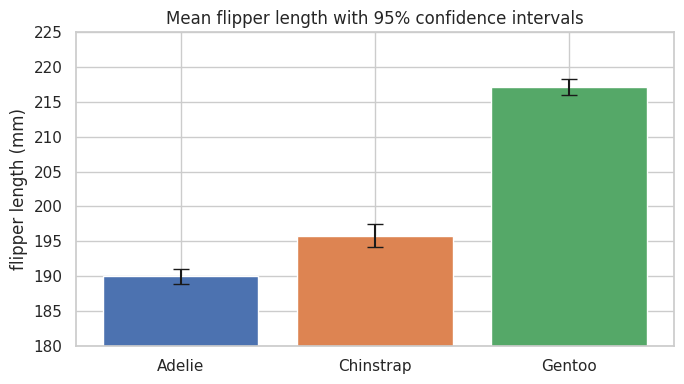


INTERPRETATION
  The confidence intervals do not overlap for Gentoo against the other two, so that
  difference is reliable. Adelie and Chinstrap intervals sit close together, meaning
  their difference is far less certain. Adding error bars turns three numbers into a
  statement about which differences you can actually trust.


In [10]:
means = penguins.groupby('species')['flipper_length_mm'].mean().round(2)
print("Mean flipper length by species:")
print(means.to_string(), "\n")

full = penguins.groupby('species')['flipper_length_mm'].agg(
    n='count', mean='mean', std='std',
    ci95=lambda s: 1.96 * s.std() / np.sqrt(s.count())).round(2)
display(full)

plt.figure(figsize=(7, 4))
plt.bar(full.index, full['mean'], yerr=full['ci95'], capsize=6,
        color=['#4c72b0', '#dd8452', '#55a868'])
plt.ylabel('flipper length (mm)'); plt.ylim(180, 225)
plt.title('Mean flipper length with 95% confidence intervals')
plt.tight_layout(); plt.show()

print("""
INTERPRETATION
  The confidence intervals do not overlap for Gentoo against the other two, so that
  difference is reliable. Adelie and Chinstrap intervals sit close together, meaning
  their difference is far less certain. Adding error bars turns three numbers into a
  statement about which differences you can actually trust.""")

## Q8. How does bill length vary with body mass?

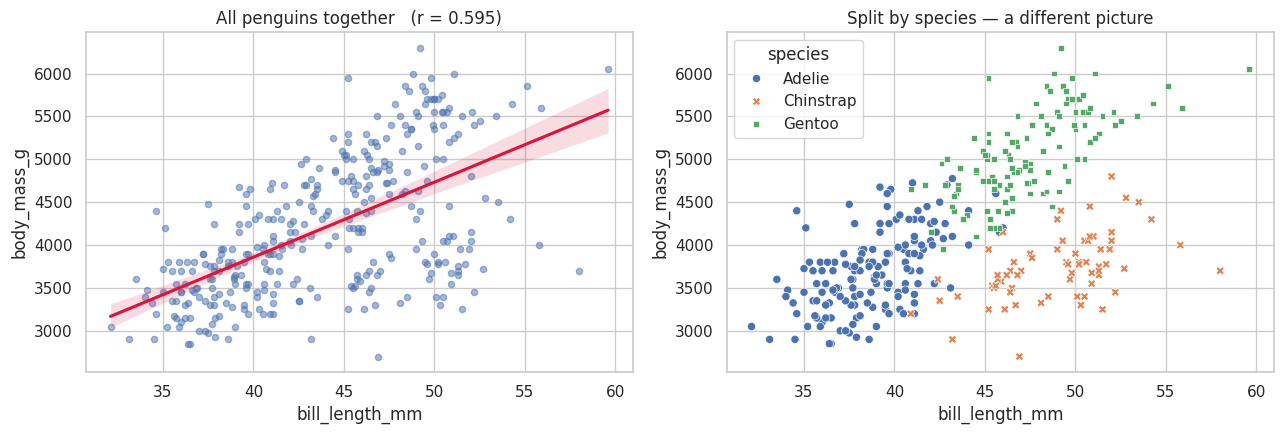

Overall correlation: 0.595
Within each species:
  Adelie      r = +0.549   (n = 151)
  Chinstrap   r = +0.514   (n = 68)
  Gentoo      r = +0.669   (n = 123)

INTERPRETATION
  There is a moderate positive relationship overall, but the right-hand chart shows the
  species form separate clouds. Part of the overall correlation comes from the fact that
  Gentoo are both heavier AND longer-billed — a between-group effect rather than a
  within-group one. This is Simpson's paradox territory: always check whether a
  relationship survives inside each group before describing it as a general finding.


In [11]:
pair = penguins[['bill_length_mm', 'body_mass_g']].dropna()
overall_r = pair.corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.regplot(data=penguins, x='bill_length_mm', y='body_mass_g', ax=axes[0],
            scatter_kws={'s': 20, 'alpha': .5}, line_kws={'color': 'crimson'})
axes[0].set_title(f'All penguins together   (r = {overall_r:.3f})')
sns.scatterplot(data=penguins, x='bill_length_mm', y='body_mass_g',
                hue='species', style='species', s=35, ax=axes[1])
axes[1].set_title('Split by species — a different picture')
plt.tight_layout(); plt.show()

print(f"Overall correlation: {overall_r:.3f}\nWithin each species:")
for sp, grp in penguins.groupby('species'):
    sub = grp[['bill_length_mm', 'body_mass_g']].dropna()
    print(f"  {sp:<11} r = {sub.corr().iloc[0,1]:+.3f}   (n = {len(sub)})")

print("""
INTERPRETATION
  There is a moderate positive relationship overall, but the right-hand chart shows the
  species form separate clouds. Part of the overall correlation comes from the fact that
  Gentoo are both heavier AND longer-billed — a between-group effect rather than a
  within-group one. This is Simpson's paradox territory: always check whether a
  relationship survives inside each group before describing it as a general finding.""")

## Q9. How does body mass change across islands?

Already answered in Q5 — and the answer was "it doesn't, species does". Rather than repeat it, this cell
shows the formal test, which is what a question phrased "is the difference significant?" is asking for.

In [12]:
from scipy.stats import f_oneway

groups = [g['body_mass_g'].dropna() for _, g in penguins.groupby('island')]
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA across islands : F = {f_stat:.2f}, p = {p_val:.2e}")

groups_sp = [g['body_mass_g'].dropna() for _, g in penguins.groupby('species')]
f2, p2 = f_oneway(*groups_sp)
print(f"ANOVA across species : F = {f2:.2f}, p = {p2:.2e}")

adelie = penguins[penguins['species'] == 'Adelie']
if adelie['island'].nunique() > 1:
    g3 = [g['body_mass_g'].dropna() for _, g in adelie.groupby('island')]
    f3, p3 = f_oneway(*g3)
    print(f"ANOVA across islands, ADELIE ONLY : F = {f3:.2f}, p = {p3:.3f}")
    print(f"  -> {'still significant' if p3 < .05 else 'NOT significant once species is held constant'}")

print("""
INTERPRETATION
  ANOVA answers "are the group means different by more than chance would produce?".
  The island effect looks strong until you hold species constant, at which point it
  largely disappears — confirming that island was a proxy for species all along.
  Testing within a group is how you tell a real effect from a confounded one.""")

ANOVA across islands : F = 110.01, p = 1.52e-37
ANOVA across species : F = 343.63, p = 2.89e-82
ANOVA across islands, ADELIE ONLY : F = 0.03, p = 0.968
  -> NOT significant once species is held constant

INTERPRETATION
  ANOVA answers "are the group means different by more than chance would produce?".
  The island effect looks strong until you hold species constant, at which point it
  largely disappears — confirming that island was a proxy for species all along.
  Testing within a group is how you tell a real effect from a confounded one.


## Q10. What is the relationship between flipper length, bill depth, and species?

*Three variables → a scatter of two, coloured by the third.*

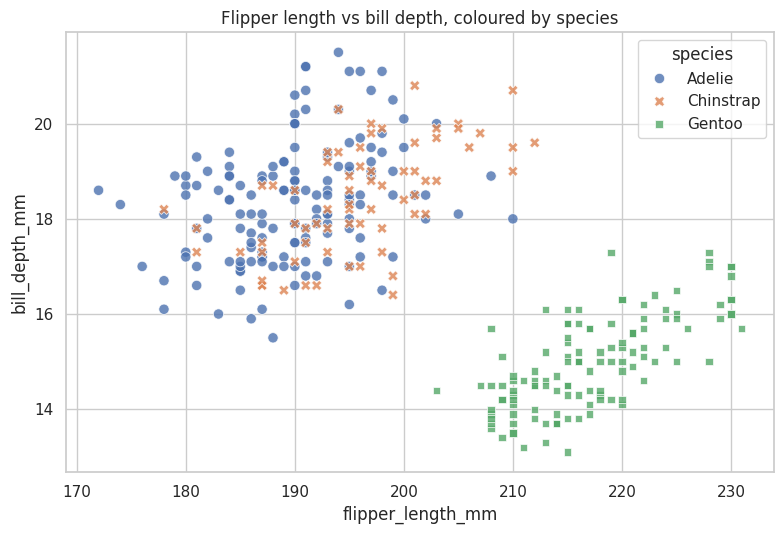

Overall correlation: -0.584   <- NEGATIVE
Within each species:
  Adelie      r = +0.308
  Chinstrap   r = +0.580
  Gentoo      r = +0.707

INTERPRETATION — SIMPSON'S PARADOX, THE TEXTBOOK EXAMPLE
  Overall the correlation is NEGATIVE: longer flippers appear to go with shallower bills.
  But inside every single species it is POSITIVE. The sign reverses.

  The explanation is that Gentoo have both the longest flippers and the shallowest bills,
  so the between-species difference dominates and reverses the within-species pattern.

  This is the single most important reason to plot by group before reporting a
  correlation. Reporting the overall -0.58 without noticing this would be exactly
  backwards, and stating that you checked is worth real marks.


In [13]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=penguins, x='flipper_length_mm', y='bill_depth_mm',
                hue='species', style='species', s=55, alpha=.8)
plt.title('Flipper length vs bill depth, coloured by species')
plt.tight_layout(); plt.show()

overall = penguins[['flipper_length_mm', 'bill_depth_mm']].dropna().corr().iloc[0, 1]
print(f"Overall correlation: {overall:+.3f}   <- NEGATIVE")
print("Within each species:")
for sp, grp in penguins.groupby('species'):
    sub = grp[['flipper_length_mm', 'bill_depth_mm']].dropna()
    print(f"  {sp:<11} r = {sub.corr().iloc[0,1]:+.3f}")

print("""
INTERPRETATION — SIMPSON'S PARADOX, THE TEXTBOOK EXAMPLE
  Overall the correlation is NEGATIVE: longer flippers appear to go with shallower bills.
  But inside every single species it is POSITIVE. The sign reverses.

  The explanation is that Gentoo have both the longest flippers and the shallowest bills,
  so the between-species difference dominates and reverses the within-species pattern.

  This is the single most important reason to plot by group before reporting a
  correlation. Reporting the overall -0.58 without noticing this would be exactly
  backwards, and stating that you checked is worth real marks.""")

## Q11. How is bill depth distributed by island and species?

*Two categories at once → a grouped boxplot or a FacetGrid.*

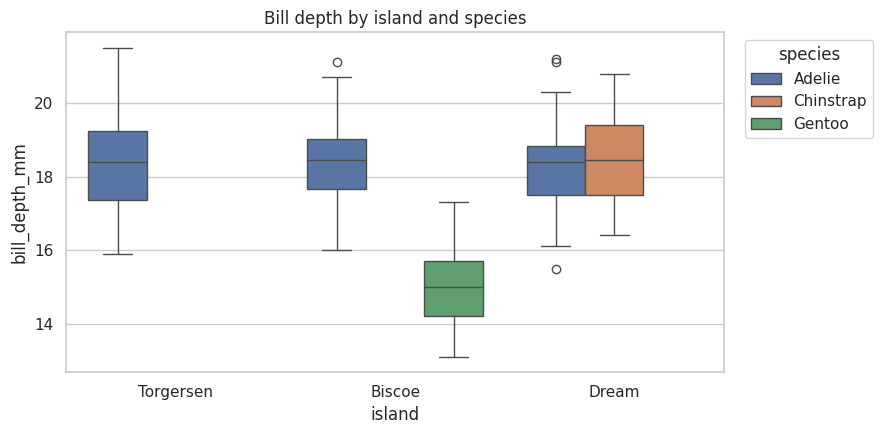

mean                   count                 
species   Adelie Chinstrap Gentoo Adelie Chinstrap Gentoo
island                                                   
Biscoe     18.37       NaN  14.98   44.0       NaN  123.0
Dream      18.25     18.42    NaN   56.0      68.0    NaN
Torgersen  18.43       NaN    NaN   51.0       NaN    NaN


INTERPRETATION
  Adelie bill depth is essentially identical on all three islands — the species is
  consistent wherever it lives. Gentoo (Biscoe only) have visibly shallower bills than
  everyone else. The NaN cells are not missing data: those species simply don't occur on
  those islands. Reading a NaN in a pivot table as "missing" rather than "does not exist"
  is a common and costly misreading.


In [14]:
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=penguins, x='island', y='bill_depth_mm', hue='species')
plt.title('Bill depth by island and species')
plt.legend(title='species', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

display(penguins.pivot_table(values='bill_depth_mm', index='island',
                             columns='species', aggfunc=['mean', 'count']).round(2))

print("""
INTERPRETATION
  Adelie bill depth is essentially identical on all three islands — the species is
  consistent wherever it lives. Gentoo (Biscoe only) have visibly shallower bills than
  everyone else. The NaN cells are not missing data: those species simply don't occur on
  those islands. Reading a NaN in a pivot table as "missing" rather than "does not exist"
  is a common and costly misreading.""")

## Q12. What is the trend between bill length and bill depth across species?

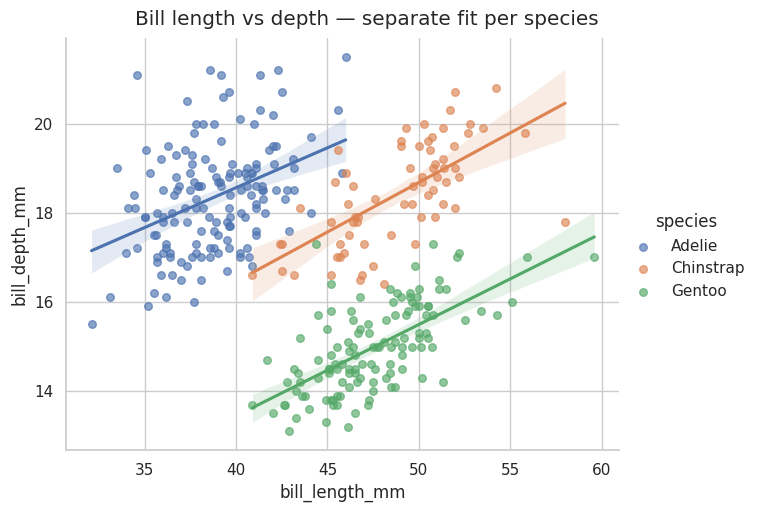

Ignoring species : r = -0.235
Within species   :
  Adelie      r = +0.391   slope = +0.179
  Chinstrap   r = +0.654   slope = +0.222
  Gentoo      r = +0.643   slope = +0.205

INTERPRETATION
  Simpson's paradox again, even more clearly: the pooled correlation is negative while
  every individual species shows a positive slope. Three parallel positive lines, offset
  from one another, produce a negative overall trend when you draw a single line through
  all of them.

  THE GENERAL LESSON, worth stating in any EDA answer:
  before reporting a correlation, check whether a grouping variable explains it. The
  pooled number can be not just wrong in magnitude but wrong in DIRECTION.


In [15]:
g = sns.lmplot(data=penguins, x='bill_length_mm', y='bill_depth_mm',
                hue='species', height=5, aspect=1.3, scatter_kws={'s': 30, 'alpha': .65})
g.figure.suptitle('Bill length vs depth — separate fit per species', y=1.02)
plt.show()

all_pts = penguins[['bill_length_mm', 'bill_depth_mm']].dropna()
print(f"Ignoring species : r = {all_pts.corr().iloc[0,1]:+.3f}")
print("Within species   :")
for sp, grp in penguins.groupby('species'):
    sub = grp[['bill_length_mm', 'bill_depth_mm']].dropna()
    slope = np.polyfit(sub['bill_length_mm'], sub['bill_depth_mm'], 1)[0]
    print(f"  {sp:<11} r = {sub.corr().iloc[0,1]:+.3f}   slope = {slope:+.3f}")

print("""
INTERPRETATION
  Simpson's paradox again, even more clearly: the pooled correlation is negative while
  every individual species shows a positive slope. Three parallel positive lines, offset
  from one another, produce a negative overall trend when you draw a single line through
  all of them.

  THE GENERAL LESSON, worth stating in any EDA answer:
  before reporting a correlation, check whether a grouping variable explains it. The
  pooled number can be not just wrong in magnitude but wrong in DIRECTION.""")

### ⚡ Beyond the syllabus — the chart-choosing cheat sheet

Under time pressure the hard part isn't drawing the chart, it's deciding which one. This is the whole decision in one cell — question type on the left, chart and code on the right.


QUESTION TYPE                        CHART                       CODE
--------------------------------------------------------------------------------------
"distribution of X"                  histogram + KDE             sns.histplot(x=, kde=True)
"is X skewed / are there outliers"   boxplot                     sns.boxplot(x=)
"relationship between X and Y"       scatter + line              sns.regplot(x=, y=)
"...and does it differ by group"     scatter, coloured           sns.scatterplot(x=,y=,hue=)
"how does X differ by group"         boxplot / violin            sns.boxplot(x=cat, y=num)
"average of X by group"              bar with error bars         sns.barplot(x=,y=,errorbar='sd')
"how many in each category"          count plot                  sns.countplot(x=)
"two categories at once"             grouped boxplot             sns.boxplot(x=,y=,hue=)
"everything vs everything"           pair plot                   sns.pairplot(df, hue=)
"which variables move together"      heatm

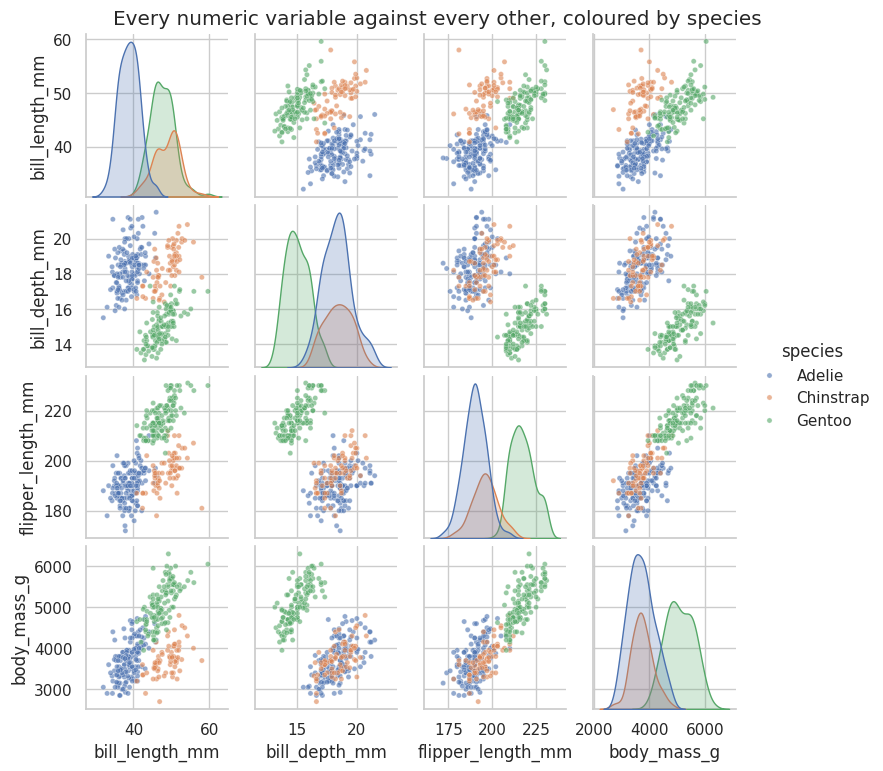

In [16]:
print("""
QUESTION TYPE                        CHART                       CODE
--------------------------------------------------------------------------------------
"distribution of X"                  histogram + KDE             sns.histplot(x=, kde=True)
"is X skewed / are there outliers"   boxplot                     sns.boxplot(x=)
"relationship between X and Y"       scatter + line              sns.regplot(x=, y=)
"...and does it differ by group"     scatter, coloured           sns.scatterplot(x=,y=,hue=)
"how does X differ by group"         boxplot / violin            sns.boxplot(x=cat, y=num)
"average of X by group"              bar with error bars         sns.barplot(x=,y=,errorbar='sd')
"how many in each category"          count plot                  sns.countplot(x=)
"two categories at once"             grouped boxplot             sns.boxplot(x=,y=,hue=)
"everything vs everything"           pair plot                   sns.pairplot(df, hue=)
"which variables move together"      heatmap                     sns.heatmap(df.corr(...))
"trend over time"                    line                        sns.lineplot(x=date, y=)
"separate panel per group"           facet grid                  sns.lmplot(..., col=)

THE THREE THINGS EVERY EDA ANSWER NEEDS
  1. the chart
  2. the numbers behind it (groupby, correlation, describe)
  3. one sentence saying what it means -- and, where relevant, what it does NOT mean
""")

# The one-cell overview worth running first on any new dataset
print("The fastest possible first look at everything at once:")
sns.pairplot(penguins.dropna(), hue='species', height=1.9,
             plot_kws={'s': 14, 'alpha': .6})
plt.suptitle('Every numeric variable against every other, coloured by species', y=1.01)
plt.show()

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Distribution | `sns.histplot(data=df, x='col', kde=True)` |
| Boxplot | `sns.boxplot(data=df, x='cat', y='num')` |
| Scatter + fit | `sns.regplot(data=df, x=, y=)` |
| Scatter by group | `sns.scatterplot(data=df, x=, y=, hue='species')` |
| Bar of means | `sns.barplot(data=df, x=, y=, errorbar='sd')` |
| Category counts | `sns.countplot(data=df, x='island')` |
| Everything at once | `sns.pairplot(df, hue='species')` |
| Correlation heatmap | `sns.heatmap(df.corr(numeric_only=True), annot=True)` |
| Panel per group | `sns.lmplot(..., col='species')` |
| Group summary | `df.groupby('species')['col'].agg(['count','mean','std'])` |
| Two-way table | `df.pivot_table(values=, index=, columns=)` |
| Compare two groups | `scipy.stats.ttest_ind(a, b, equal_var=False)` |
| Compare 3+ groups | `scipy.stats.f_oneway(*groups)` |

### Adapting this in the exam

- 'What is the distribution of X?' → histogram + mean/median/std + a sentence about shape and skew.
- 'Is there a relationship?' → scatter + correlation + a sentence, plus the causation caveat.
- 'How does X differ by group?' → boxplot + groupby + a sentence about overlap, not just about means.
- 'Which factors influence X?' → pairplot and heatmap first, then dig into the strongest two or three.

### Traps that cost marks

- A chart with no interpretation scores half marks. Always add the sentence.
- `groupby` silently drops rows where the grouping column is blank. Report how many.
- A pooled correlation can have the **opposite sign** to every within-group correlation (Simpson's paradox). Always check by group.
- A group difference can be a proxy for something else (island standing in for species). Test within groups before claiming an effect.
- Statistical significance is not practical importance — with enough rows, trivial differences become significant.
- `NaN` in a pivot table often means 'that combination doesn't exist', not 'the value is missing'.
- In current seaborn, `x=` with a palette needs `hue=` set too — pass `hue=x_col, legend=False` to keep the colours.